# CNN Model for Neonatal Audio - Respiratory Distress Classification
Based on SPRSound Dataset: https://github.com/SJTU-YONGFU-RESEARCH-GRP/SPRSound

## 1. Import libraries

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import os
import json
import requests
import io
import shap
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T
import torch.nn.functional as F
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam import HiResCAM

from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_recall_fscore_support, roc_auc_score, roc_curve,
    auc, matthews_corrcoef, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

In [88]:
GITHUB_TOKEN = "***REMOVED***"
headers = {"Authorization": f"token {GITHUB_TOKEN}"}

def get_all_audio_urls(api_url):
    urls = []
    response = requests.get(api_url, headers=headers)
    files = response.json()

    for file in files:
        if file["type"] == "dir":
            urls.extend(get_all_audio_urls(file["url"]))
        elif file["name"].endswith(".wav"):
            urls.append(file["download_url"])
    return urls

In [89]:
def get_json_labels_from_github(api_url):

    labels_dict = {}
    response = requests.get(api_url).json()

    label_map = {
        "Normal": 0,
        "CAS": 1,
        "DAS": 1,
        "CAS & DAS": 1
    }

    for file in response:
        if file['name'].endswith(".json"):

            json_url = file['download_url']
            r = requests.get(json_url)
            data = r.json()

            label_str = data["record_annotation"]

            if label_str == "Poor Quality":
                continue

            label = label_map[label_str]

            wav_name = file['name'].replace(".json", ".wav")
            labels_dict[wav_name] = label

    return labels_dict

In [90]:
train_labels_dict = get_json_labels_from_github(
    "https://api.github.com/repos/SJTU-YONGFU-RESEARCH-GRP/SPRSound/contents/BioCAS2022/train2022_json"
)

In [91]:
test_intra_labels = get_json_labels_from_github(
    "https://api.github.com/repos/SJTU-YONGFU-RESEARCH-GRP/SPRSound/contents/BioCAS2022/test2022_json/intra_test_json"
)

test_inter_labels = get_json_labels_from_github(
    "https://api.github.com/repos/SJTU-YONGFU-RESEARCH-GRP/SPRSound/contents/BioCAS2022/test2022_json/inter_test_json"
)

# Combine both
test_labels_dict = {**test_intra_labels, **test_inter_labels}

In [92]:
def pad_or_truncate(mel, max_len=500):
    time_frames = mel.shape[1]
    if time_frames < max_len:
        pad_width = max_len - time_frames
        mel = np.pad(mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel = mel[:, :max_len]
    return mel

In [93]:
audio_cache = {}

class StreamingAudioDataset(Dataset):

    def __init__(self, urls, labels, max_len=500):
        self.urls = urls
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        url = self.urls[idx]

        if url in audio_cache:
            audio_bytes = audio_cache[url]
        else:
            response = requests.get(url, headers=headers)
            audio_bytes = response.content
            audio_cache[url] = audio_bytes

        audio_stream = io.BytesIO(audio_bytes)
        y, sr = librosa.load(audio_stream, sr=16000)

        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel)
        mel_db = pad_or_truncate(mel_db, self.max_len)

        mel_db = torch.tensor(mel_db).unsqueeze(0).float()
        label = torch.tensor(self.labels[idx]).long()

        return mel_db, label

In [96]:
train_api = "https://api.github.com/repos/SJTU-YONGFU-RESEARCH-GRP/SPRSound/contents/BioCAS2022/train2022_wav"
test_api  = "https://api.github.com/repos/SJTU-YONGFU-RESEARCH-GRP/SPRSound/contents/BioCAS2022/test2022_wav"

train_urls = get_all_audio_urls(train_api)
test_urls  = get_all_audio_urls(test_api)

filtered_train_urls = [url for url in train_urls if url.split("/")[-1] in train_labels_dict]
train_labels = [train_labels_dict[url.split("/")[-1]] for url in filtered_train_urls]

filtered_test_urls = [url for url in test_urls if url.split("/")[-1] in test_labels_dict]
test_labels = [test_labels_dict[url.split("/")[-1]] for url in filtered_test_urls]

print("Train label distribution:", np.unique(train_labels, return_counts=True))
print("Test label distribution:", np.unique(test_labels, return_counts=True))

Train label distribution: (array([0, 1]), array([643, 258]))
Test label distribution: (array([0, 1]), array([482, 242]))


In [97]:
max_len = 500
batch_size = 8

train_dataset = StreamingAudioDataset(filtered_train_urls, train_labels)
test_dataset  = StreamingAudioDataset(filtered_test_urls, test_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [98]:
class AudioCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(AudioCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=(3,3), padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=(3,3), padding=1)
        self.pool  = nn.MaxPool2d((2,2))
        self.fc1   = nn.Linear(32*32*125, 128)  # depends on input size [1,128,500]
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [99]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AudioCNN(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for data, labels in train_loader:
        data, labels = data.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/5, Loss: 4.4067
Epoch 2/5, Loss: 0.5246
Epoch 3/5, Loss: 0.4688
Epoch 4/5, Loss: 0.3905
Epoch 5/5, Loss: 0.3118


In [100]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, labels in test_loader:
        data, labels = data.to(device), labels.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100*correct/total:.2f}%")

Test Accuracy: 68.23%


In [101]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        data, labels = data.to(device), labels.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute metrics
precision = precision_score(all_labels, all_preds, average='binary')
recall    = recall_score(all_labels, all_preds, average='binary')
f1        = f1_score(all_labels, all_preds, average='binary')

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Precision: 0.5330
Recall:    0.4008
F1 Score:  0.4575


In [102]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:

        data, labels = data.to(device), labels.to(device)

        outputs = model(data)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [103]:
cm = confusion_matrix(all_labels, all_preds)

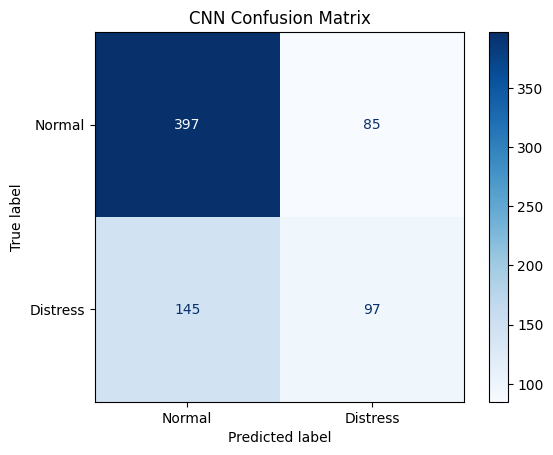

In [106]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Distress"]
)

disp.plot(cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.show()

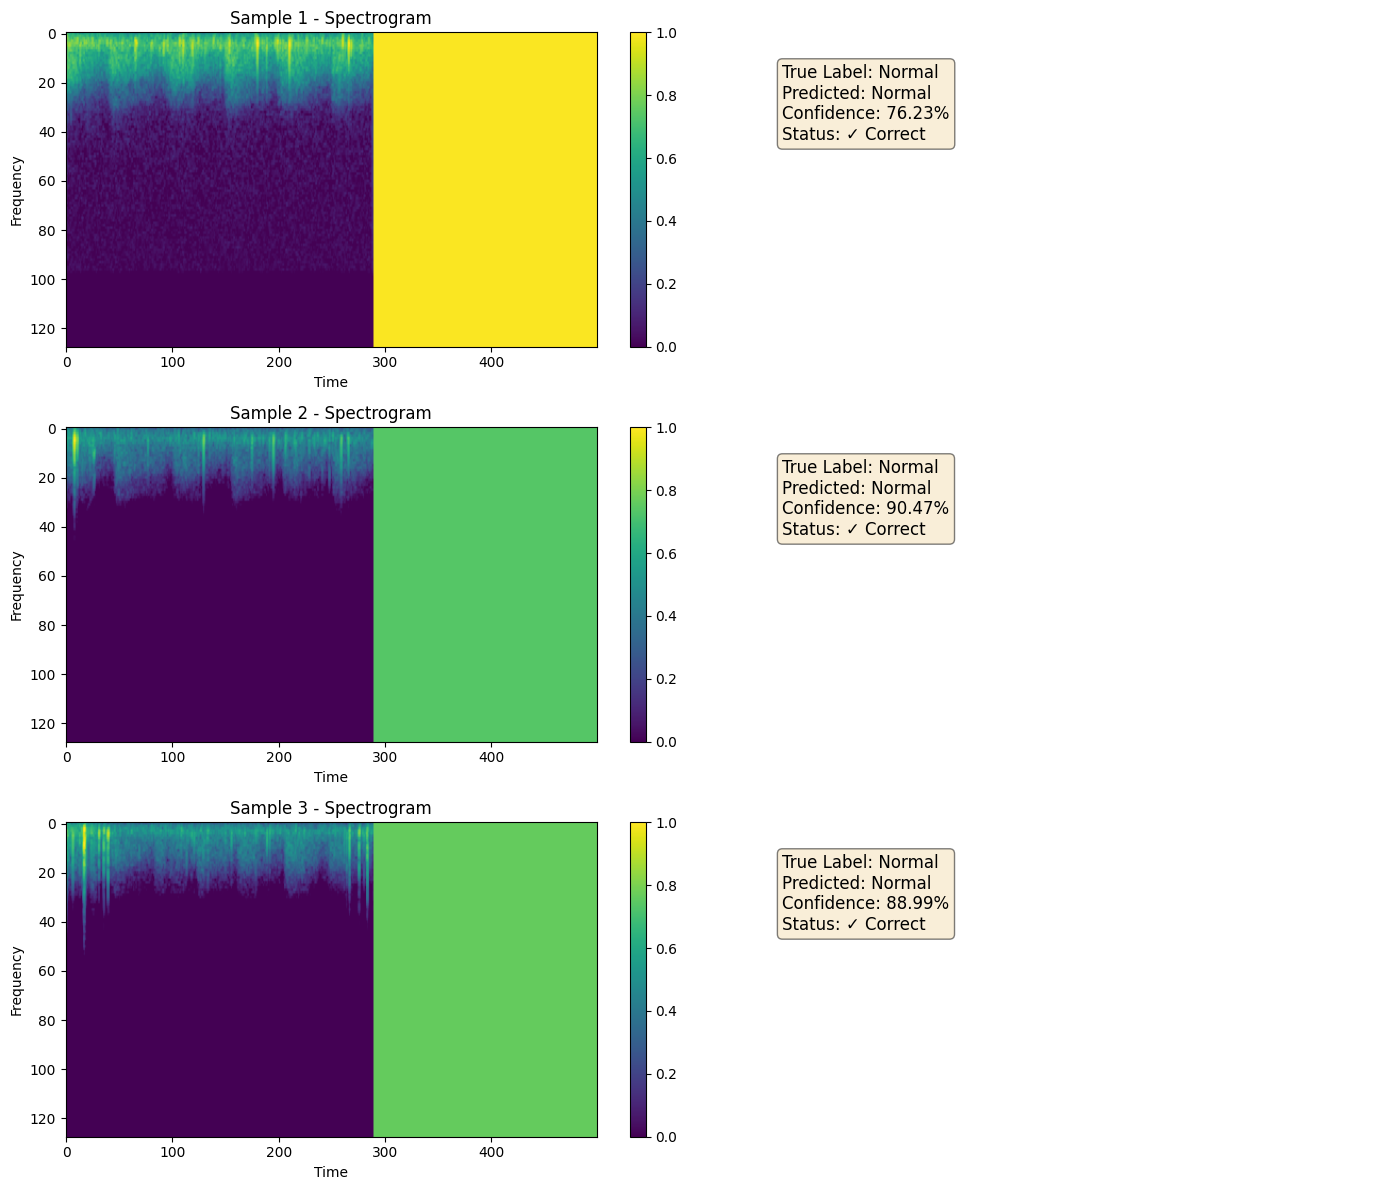

✅ Visualization complete - Displayed 8 test samples with predictions


In [125]:
# Model prediction and spectrogram visualization

model.eval()

# Get multiple samples for visualization
all_samples = []
all_true_labels = []
all_preds_vis = []
all_confidence = []

with torch.no_grad():
    for data, true_labels in test_loader:
        data = data.to(device)
        outputs = model(data)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        
        for i in range(len(data)):
            all_samples.append(data[i].cpu().numpy())
            all_true_labels.append(true_labels[i].item())
            all_preds_vis.append(preds[i].item())
            all_confidence.append(probs[i, preds[i]].item())
        
        if len(all_samples) >= 3:
            break

# Visualize 3 samples
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

class_names = ['Normal', 'Respiratory Distress']

for idx in range(3):
    spec = all_samples[idx][0]
    true_label = all_true_labels[idx]
    pred_label = all_preds_vis[idx]
    confidence = all_confidence[idx]
    
    # Normalize for display
    spec_display = (spec - spec.min()) / (spec.max() - spec.min() + 1e-8)
    
    # Original spectrogram
    im = axes[idx, 0].imshow(spec_display, cmap='viridis', aspect='auto')
    axes[idx, 0].set_title(f'Sample {idx+1} - Spectrogram')
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].set_xlabel('Time')
    plt.colorbar(im, ax=axes[idx, 0])
    
    # Prediction info
    true_text = f'True Label: {class_names[true_label]}\n'
    pred_text = f'Predicted: {class_names[pred_label]}\n'
    conf_text = f'Confidence: {confidence:.2%}\n'
    correct_text = f'Status: {"✓ Correct" if true_label == pred_label else "✗ Incorrect"}'
    
    axes[idx, 1].text(0.1, 0.9, true_text + pred_text + conf_text + correct_text,
                      transform=axes[idx, 1].transAxes,
                      fontsize=12, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"✅ Visualization complete - Displayed {len(all_samples)} test samples with predictions")